# 01 · Book-Crossing — data understanding

**Purpose.** Understand the dataset well enough to make the modelling decisions
consciously rather than by habit. Every section answers one question, shows the
computation, and ends in a takeaway that has consequences for the PoC.

**What this notebook is not.** It is not a model. It deliberately stops at the point
where the data tells us what to build.

**Ground truth.** The numbers here are cross-checked against
`docs/dataset_findings.md` (profiled on these CSVs on 2026-08-03).
Section 9 runs that comparison automatically and prints any deviation.

**Reproducibility.** Reads only from `data/`, no network, no sampling anywhere — the
notebook is deterministic by construction, so no seed is needed. Runs top to bottom
on a fresh kernel.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Find the project root from wherever the kernel was started (repo root or notebooks/).
ROOT = Path.cwd()
while not (ROOT / "data").is_dir() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
DATA = ROOT / "data"
IMG = ROOT / "docs" / "img"
IMG.mkdir(parents=True, exist_ok=True)

if not (DATA / "Ratings.csv").exists():
    raise FileNotFoundError(
        f"Book-Crossing CSVs not found in {DATA}. Download the Kaggle dataset "
        "'arashnic/book-recommendation-dataset' and place Books.csv, Ratings.csv, "
        "Users.csv there (see README)."
    )

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 60)

# Headline numbers are collected here and checked against the ground-truth doc in §9.
H = {}

print("project root:", ROOT)

project root: /path/to/recommender


---
## 1 · Load & shape

**What and why.** Three files, one join key (`ISBN`) and one user key (`User-ID`).
Before anything else we need to know how big each table is, whether the keys line up,
and whether the files are actually clean. Book-Crossing is a 2004 web crawl, so the
answer to the last question is "not entirely" — and the interesting part is *how* it
is dirty, because that lands in the data-prep layer later.

In [2]:
books_raw = pd.read_csv(DATA / "Books.csv", dtype=str)
ratings = pd.read_csv(
    DATA / "Ratings.csv",
    dtype={"User-ID": "int64", "ISBN": "str", "Book-Rating": "int64"},
)
users = pd.read_csv(
    DATA / "Users.csv",
    dtype={"User-ID": "int64", "Location": "str", "Age": "float64"},
)

for name, df in [("Books", books_raw), ("Ratings", ratings), ("Users", users)]:
    print(f"{name:8s} {len(df):>9,} rows x {df.shape[1]} cols   {list(df.columns)}")

H["n_ratings"] = len(ratings)
H["n_books"] = len(books_raw)
H["n_users"] = len(users)

Books      271,360 rows x 8 cols   ['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L']
Ratings  1,149,780 rows x 3 cols   ['User-ID', 'ISBN', 'Book-Rating']
Users      278,858 rows x 3 cols   ['User-ID', 'Location', 'Age']


### 1b · The three malformed rows in Books.csv

`Books.csv` has three records where the book title contains an unescaped `\";`.
The CSV parser reads the merged *title + author* as one field, so every following
column is shifted one position to the left and `Image-URL-L` ends up empty.

They are easy to *silently* lose (`on_bad_lines="skip"` would drop them without a
word). We repair them instead and count what happened — three rows do not change any
number in this notebook, but "we know exactly what our loader does to broken input"
is the habit that matters when the same loader meets client data.

In [3]:
YEAR = "Year-Of-Publication"
COLS = ["Book-Title", "Book-Author", YEAR, "Publisher", "Image-URL-S", "Image-URL-M", "Image-URL-L"]

# A non-numeric year is the fingerprint of the column shift.
year_numeric = pd.to_numeric(books_raw[YEAR], errors="coerce")
malformed = year_numeric.isna() & books_raw[YEAR].notna()
print(f"malformed rows detected: {malformed.sum()}")
print("\nAS PARSED (columns shifted by one):")
display(books_raw.loc[malformed, ["ISBN"] + COLS[:4]])


def repair_shifted_rows(df, mask):
    """Un-shift the rows whose title+author were merged into a single CSV field."""
    fixed = df.copy()
    for i in df.index[mask]:
        row = df.loc[i]
        title, _, author = str(row["Book-Title"]).partition('\\";')
        shifted = [row["Book-Author"], row[YEAR], row["Publisher"], row["Image-URL-S"], row["Image-URL-M"]]
        fixed.loc[i, COLS] = [title, author.rstrip('"'), *shifted]
    return fixed


books = repair_shifted_rows(books_raw, malformed)
print("\nAFTER REPAIR:")
display(books.loc[malformed, ["ISBN"] + COLS[:4]])

n_dropped = len(books_raw) - len(books)
print(f"\nrows repaired: {malformed.sum()}   rows dropped: {n_dropped}   rows kept: {len(books):,}")
H["n_malformed"] = int(malformed.sum())
H["n_dropped"] = n_dropped

malformed rows detected: 3

AS PARSED (columns shifted by one):


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
209538,078946697X,"DK Readers: Creating the X-Men, How It All Began (Level ...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.01.THUMBZZZ...
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-Marie Gusta...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.01.THUMBZZZ...
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Books Come to ...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.01.THUMBZZZ...



AFTER REPAIR:


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
209538,078946697X,"DK Readers: Creating the X-Men, How It All Began (Level ...",Michael Teitelbaum,2000,DK Publishing Inc
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers",Jean-Marie Gustave Le ClÃ?Â©zio,2003,Gallimard
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Books Come to ...",James Buckley,2000,DK Publishing Inc



rows repaired: 3   rows dropped: 0   rows kept: 271,360


In [4]:
# Year-of-publication is dirty in a second, milder way: placeholder zeros and future years.
year = pd.to_numeric(books[YEAR], errors="coerce")
H["year_zero"] = int((year == 0).sum())
H["year_future"] = int((year > 2006).sum())  # the crawl is from 2004
print(f"Year-Of-Publication == 0 (placeholder) : {H['year_zero']:,}")
print(f"Year-Of-Publication  > 2006 (impossible): {H['year_future']:,}")
print(f"plausible years 1376-2006              : {int(year.between(1376, 2006).sum()):,}")

Year-Of-Publication == 0 (placeholder) : 4,618
Year-Of-Publication  > 2006 (impossible): 23
plausible years 1376-2006              : 266,719


**Takeaway.** The tables are large but the join surface is narrow — `ISBN` and
`User-ID` are all that connect them — and the raw files carry parser-level damage that
a loader must handle deliberately rather than skip.

---
## 2 · Explicit vs implicit — the biggest design decision in the dataset

**What and why.** `Book-Rating` runs 0–10, but 0 does not mean "rated zero". In
Book-Crossing a 0 is an *implicit* interaction: the user touched the book without
grading it. That single convention decides how much data we actually have, so it has
to be a decision we take on purpose, not a filtering reflex.

In [5]:
n_ratings = len(ratings)
implicit = ratings["Book-Rating"] == 0
explicit = ratings.loc[~implicit]

H["implicit_n"] = int(implicit.sum())
H["implicit_share"] = implicit.mean()
H["explicit_n"] = len(explicit)
H["explicit_mean"] = explicit["Book-Rating"].mean()
H["explicit_mode"] = int(explicit["Book-Rating"].mode().iloc[0])

print(f"implicit (rating = 0) : {H['implicit_n']:>9,}  ({H['implicit_share']:.1%})")
print(f"explicit (rating 1-10): {H['explicit_n']:>9,}  ({1 - H['implicit_share']:.1%})")
print(f"\nexplicit mean {H['explicit_mean']:.2f}   median {explicit['Book-Rating'].median():.0f}   "
      f"mode {H['explicit_mode']}")
print("\nexplicit distribution:")
print(explicit["Book-Rating"].value_counts().sort_index().to_string())

implicit (rating = 0) :   716,109  (62.3%)
explicit (rating 1-10):   433,671  (37.7%)

explicit mean 7.60   median 8   mode 8

explicit distribution:
Book-Rating
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610


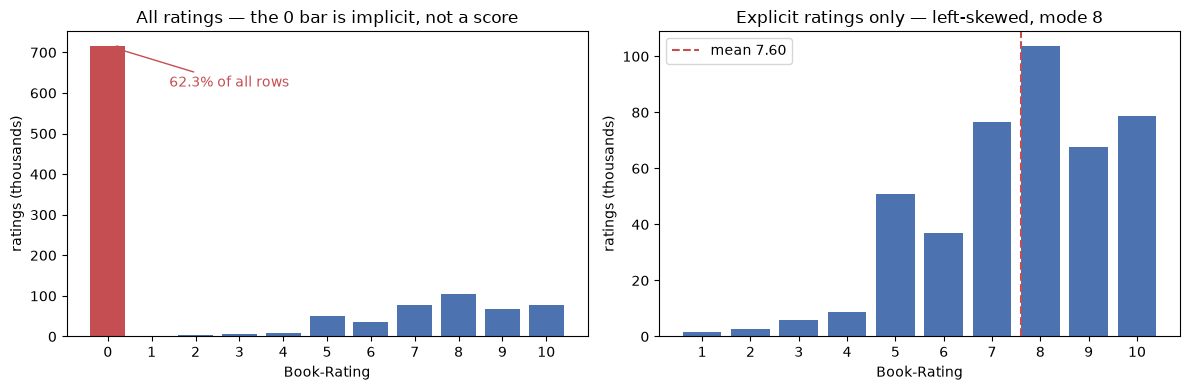

In [6]:
counts_all = ratings["Book-Rating"].value_counts().sort_index()
counts_exp = explicit["Book-Rating"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ["#c44e52"] + ["#4c72b0"] * 10
axes[0].bar(counts_all.index, counts_all.to_numpy() / 1000, color=colors)
axes[0].set_title("All ratings — the 0 bar is implicit, not a score")
axes[0].set_xlabel("Book-Rating")
axes[0].set_ylabel("ratings (thousands)")
axes[0].set_xticks(range(11))
axes[0].annotate(
    f"{H['implicit_share']:.1%} of all rows",
    xy=(0, counts_all.loc[0] / 1000),
    xytext=(1.4, counts_all.loc[0] / 1000 * 0.86),
    color="#c44e52",
    arrowprops={"arrowstyle": "->", "color": "#c44e52"},
)

axes[1].bar(counts_exp.index, counts_exp.to_numpy() / 1000, color="#4c72b0")
axes[1].axvline(H["explicit_mean"], color="#c44e52", linestyle="--", label=f"mean {H['explicit_mean']:.2f}")
axes[1].set_title("Explicit ratings only — left-skewed, mode 8")
axes[1].set_xlabel("Book-Rating")
axes[1].set_ylabel("ratings (thousands)")
axes[1].set_xticks(range(1, 11))
axes[1].legend()

fig.tight_layout()
plt.show()

**Takeaway.** 62.3% of all rows carry no grade, so treating the implicit zeros as
"missing data to be cleaned away" throws away almost two thirds of the signal —
whether we keep them is a modelling decision (binarize for similarity, use the
explicit grade as a confidence weight), not a cleaning step.

---
## 3 · Sparsity & the long tail

**What and why.** Every collaborative-filtering method lives or dies on how much
overlap there is between users. Here we measure how thin the matrix is and how
unevenly the interactions are distributed — the shape of that distribution is what
later forces us to report coverage next to accuracy.

In [7]:
per_book = ratings.groupby("ISBN").size()
per_user = ratings.groupby("User-ID").size()

n_u, n_b = ratings["User-ID"].nunique(), ratings["ISBN"].nunique()
H["density_all"] = n_ratings / (n_u * n_b)
H["books_1_rating"] = (per_book == 1).mean()
H["books_lt5"] = (per_book < 5).mean()
H["users_1_rating"] = (per_user == 1).mean()

top1_n = int(np.ceil(len(per_book) * 0.01))
H["top1pct_share"] = per_book.sort_values(ascending=False).head(top1_n).sum() / n_ratings

print(f"users appearing in Ratings.csv : {n_u:,}   ({H['n_users']:,} exist in Users.csv)")
print(f"ISBNs appearing in Ratings.csv : {n_b:,}   ({H['n_books']:,} exist in Books.csv — more ISBNs are rated")
print(f"{'':33s}than the catalogue contains; §5 measures that gap)")
print(f"matrix density                 : {H['density_all']:.5%}  — 1 filled cell in ~{round(1 / H['density_all']):,}")
print()
print(f"books with exactly 1 rating    : {H['books_1_rating']:.1%}")
print(f"books with fewer than 5 ratings: {H['books_lt5']:.1%}")
print(f"users with exactly 1 rating    : {H['users_1_rating']:.1%}")
print(f"top 1% of books ({top1_n:,} titles) hold {H['top1pct_share']:.1%} of all interactions")
print()
print("ratings per book:", per_book.describe()[["mean", "50%", "max"]].to_dict())
print("ratings per user:", per_user.describe()[["mean", "50%", "max"]].to_dict())

users appearing in Ratings.csv : 105,283   (278,858 exist in Users.csv)
ISBNs appearing in Ratings.csv : 340,556   (271,360 exist in Books.csv — more ISBNs are rated
                                 than the catalogue contains; §5 measures that gap)
matrix density                 : 0.00321%  — 1 filled cell in ~31,184

books with exactly 1 rating    : 57.9%
books with fewer than 5 ratings: 87.1%
users with exactly 1 rating    : 56.2%
top 1% of books (3,406 titles) hold 25.1% of all interactions

ratings per book: {'mean': 3.376184827164989, '50%': 1.0, 'max': 2502.0}
ratings per user: {'mean': 10.920851419507423, '50%': 1.0, 'max': 13602.0}


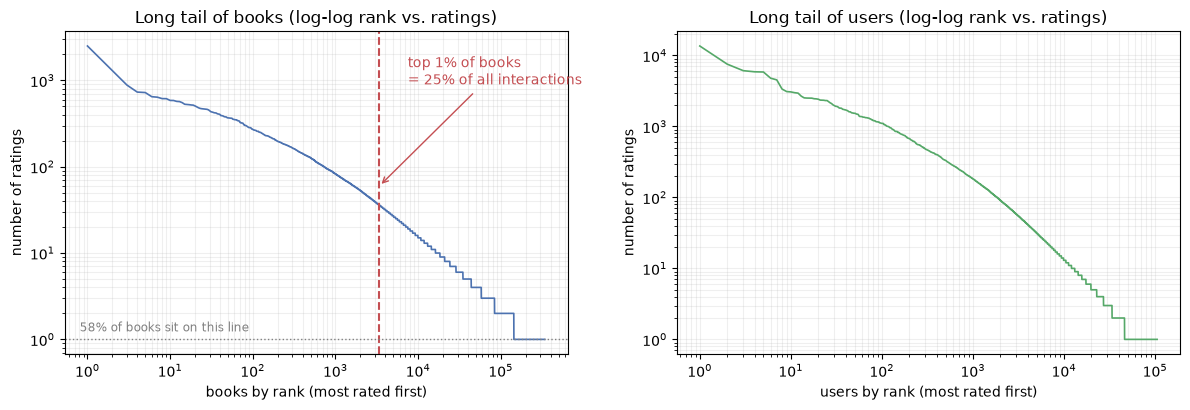

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for ax, counts, label, color in [
    (axes[0], per_book, "books", "#4c72b0"),
    (axes[1], per_user, "users", "#55a868"),
]:
    ordered = counts.sort_values(ascending=False).to_numpy()
    ax.loglog(np.arange(1, len(ordered) + 1), ordered, color=color, linewidth=1.2)
    ax.set_title(f"Long tail of {label} (log-log rank vs. ratings)")
    ax.set_xlabel(f"{label} by rank (most rated first)")
    ax.set_ylabel("number of ratings")
    ax.grid(True, which="both", alpha=0.2)

axes[0].axvline(top1_n, color="#c44e52", linestyle="--")
axes[0].annotate(
    f"top 1% of books\n= {H['top1pct_share']:.0%} of all interactions",
    xy=(top1_n, 60),
    xytext=(top1_n * 2.2, 900),
    color="#c44e52",
    arrowprops={"arrowstyle": "->", "color": "#c44e52"},
)
axes[0].axhline(1, color="grey", linestyle=":", linewidth=1)
axes[0].annotate(
    f"{H['books_1_rating']:.0%} of books sit on this line",
    xy=(0.03, 0.07),
    xycoords="axes fraction",
    color="grey",
    fontsize=8.5,
)

fig.tight_layout()
plt.show()

**Takeaway.** With ~0.003% density, 58% of books rated exactly once and a top 1% that
absorbs a quarter of all interactions, a recommender here can score well on accuracy
while only ever touching the head of the catalogue — which is why coverage and novelty
have to be measured alongside Precision@K, not instead of it.

---
## 4 · The filtering funnel — what "standard preprocessing" actually costs

**What and why.** Nearly every public notebook on this dataset applies the same
recipe: keep explicit ratings, then require at least 5 ratings per user and per book.
It is a reasonable recipe. But it is rarely quantified, and the cost is the whole
argument for the architecture we propose later — so we count it.

In [9]:
# The standard recipe: one pass, both thresholds evaluated on the explicit-only set.
MIN_RATINGS = 5
uc = explicit.groupby("User-ID").size()
bc = explicit.groupby("ISBN").size()
filtered = explicit[
    explicit["User-ID"].map(uc).ge(MIN_RATINGS) & explicit["ISBN"].map(bc).ge(MIN_RATINGS)
]

H["filtered_n"] = len(filtered)
H["filtered_users"] = filtered["User-ID"].nunique()
H["filtered_books"] = filtered["ISBN"].nunique()
H["filtered_density"] = H["filtered_n"] / (H["filtered_users"] * H["filtered_books"])
H["catalog_coverage"] = H["filtered_books"] / H["n_books"]

print(f"{'raw interactions':<34}{n_ratings:>10,}   {'':>9}")
print(f"{'explicit only':<34}{H['explicit_n']:>10,}   {H['explicit_n'] / n_ratings:>8.1%} of raw")
print(f"{'+ min 5 per user and per book':<34}{H['filtered_n']:>10,}   {H['filtered_n'] / n_ratings:>8.1%} of raw")
print()
print(f"books  {H['n_books']:>9,}  ->  {H['filtered_books']:>7,}   ({H['catalog_coverage']:.1%} of the catalogue)")
print(f"users  {H['n_users']:>9,}  ->  {H['filtered_users']:>7,}")
print(f"density {H['density_all']:.5%}  ->  {H['filtered_density']:.3%}   "
      f"({H['filtered_density'] / H['density_all']:.0f}x denser)")

raw interactions                   1,149,780            
explicit only                        433,671      37.7% of raw
+ min 5 per user and per book        152,280      13.2% of raw

books    271,360  ->   14,513   (5.3% of the catalogue)
users    278,858  ->   13,305
density 0.00321%  ->  0.079%   (25x denser)


In [10]:
# Honesty note: the single pass does not actually guarantee its own threshold.
# Removing sparse users lowers book counts, which can push books back below 5.
it = filtered
passes = 0
while True:
    before = len(it)
    it = it[it["User-ID"].map(it.groupby("User-ID").size()).ge(MIN_RATINGS)]
    it = it[it["ISBN"].map(it.groupby("ISBN").size()).ge(MIN_RATINGS)]
    passes += 1
    if len(it) == before:
        break

H["fixpoint_n"] = len(it)
H["fixpoint_users"] = it["User-ID"].nunique()
H["fixpoint_books"] = it["ISBN"].nunique()
print(f"iterated to a fixed point ({passes} passes):")
print(f"  {H['fixpoint_n']:,} ratings, {H['fixpoint_users']:,} users, {H['fixpoint_books']:,} books")
print(f"  i.e. {1 - H['fixpoint_n'] / H['filtered_n']:.0%} smaller than the single-pass result reported above.")

iterated to a fixed point (10 passes):
  118,668 ratings, 7,025 users, 9,432 books
  i.e. 22% smaller than the single-pass result reported above.


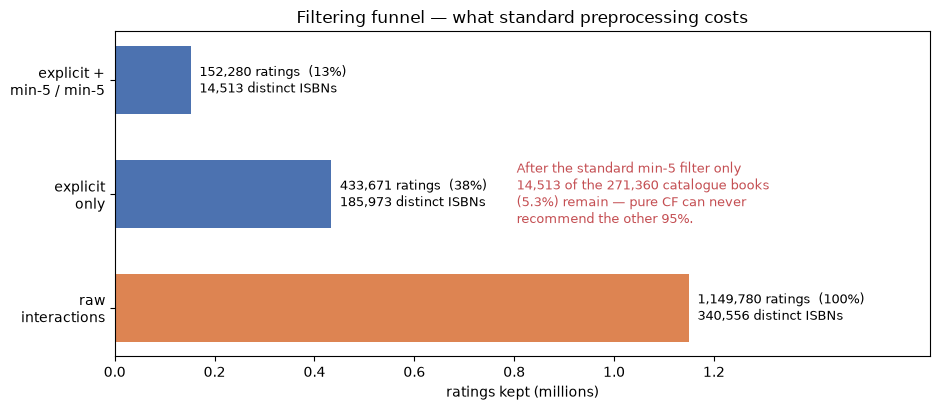

saved: docs/img/filtering_funnel.png


In [11]:
stages = ["raw\ninteractions", "explicit\nonly", "explicit +\nmin-5 / min-5"]
values = [n_ratings, H["explicit_n"], H["filtered_n"]]
isbns_left = [n_b, explicit["ISBN"].nunique(), H["filtered_books"]]

fig, ax = plt.subplots(figsize=(9.5, 4.2))
bars = ax.barh(stages[::-1], values[::-1], color=["#4c72b0", "#4c72b0", "#dd8452"], height=0.6)
ax.invert_yaxis()
ax.set_xlabel("ratings kept (millions)")
ax.set_title("Filtering funnel — what standard preprocessing costs")
ax.set_xlim(0, n_ratings * 1.42)
ax.set_xticks(np.arange(0, 1.4, 0.2) * 1e6)
ax.set_xticklabels([f"{t:.1f}" for t in np.arange(0, 1.4, 0.2)])

for bar, v, b in zip(bars, values[::-1], isbns_left[::-1], strict=True):
    ax.text(
        v + n_ratings * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{v:,} ratings  ({v / n_ratings:.0%})\n{b:,} distinct ISBNs",
        va="center",
        fontsize=9,
    )

ax.text(
    n_ratings * 0.70,
    1.0,
    f"After the standard min-5 filter only\n"
    f"{H['filtered_books']:,} of the {H['n_books']:,} catalogue books\n"
    f"({H['catalog_coverage']:.1%}) remain — pure CF can never\n"
    f"recommend the other {1 - H['catalog_coverage']:.0%}.",
    color="#c44e52",
    fontsize=9.5,
    va="center",
)
fig.tight_layout()
fig.savefig(IMG / "filtering_funnel.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved:", (IMG / "filtering_funnel.png").relative_to(ROOT))

**Takeaway.** Standard preprocessing keeps 13% of the interactions and 5.3% of the
catalogue, so a pure collaborative filter is structurally unable to say anything about
95% of the books — that is the quantified argument for a content-based layer, and it
is a coverage argument, not a cold-start footnote.

---
## 5 · Join hygiene — ISBNs that do not line up

**What and why.** The app has to *show* a book: title, author, cover. That needs the
join from `Ratings.csv` to `Books.csv` to hold. It partly does not, and separately the
same book appears under many ISBNs, which silently splits its signal across editions.

In [12]:
known_isbns = set(books["ISBN"])
unmatched = ~ratings["ISBN"].isin(known_isbns)
H["unmatched_n"] = int(unmatched.sum())
H["unmatched_share"] = unmatched.mean()
print(f"ratings whose ISBN is absent from Books.csv: {H['unmatched_n']:,}  ({H['unmatched_share']:.1%})")
print(f"distinct such ISBNs                       : {ratings.loc[unmatched, 'ISBN'].nunique():,}")
print("\nexamples of unmatched ISBNs (usable for CF, unusable for display):")
print(ratings.loc[unmatched, "ISBN"].drop_duplicates().head(6).tolist())

ratings whose ISBN is absent from Books.csv: 118,644  (10.3%)
distinct such ISBNs                       : 70,405

examples of unmatched ISBNs (usable for CF, unusable for display):
['3257224281', '0600570967', '342310538', '3442437407', '033390804X', '8440682697']


In [13]:
# Edition duplicates: same work, several ISBNs. Normalized on case and whitespace.
key = pd.DataFrame({
    "title": books["Book-Title"].str.lower().str.strip(),
    "author": books["Book-Author"].str.lower().str.strip(),
    "ISBN": books["ISBN"],
})
per_work = key.groupby(["title", "author"])["ISBN"].nunique()
dupes = per_work[per_work > 1]

H["dupe_works"] = len(dupes)
H["dupe_isbns"] = int(dupes.sum())
print(f"title+author combos with more than one ISBN: {H['dupe_works']:,}")
print(f"ISBNs involved                             : {H['dupe_isbns']:,}  "
      f"({H['dupe_isbns'] / len(books):.1%} of the catalogue)")

worst = dupes.sort_values(ascending=False).index[0]
example = books[
    (books["Book-Title"].str.lower().str.strip() == worst[0])
    & (books["Book-Author"].str.lower().str.strip() == worst[1])
]
print(f"\nmost fragmented work: '{worst[0]}' — {len(example)} ISBNs, "
      f"{int(ratings['ISBN'].isin(set(example['ISBN'])).sum()):,} ratings spread across them")
display(example[["ISBN", "Book-Title", "Book-Author", YEAR, "Publisher"]].head(8))

title+author combos with more than one ISBN: 17,554
ISBNs involved                             : 40,675  (15.0% of the catalogue)

most fragmented work: 'little women' — 23 ISBNs, 102 ratings spread across them


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
4330,0861782356,Little Women,Louisa May Alcott,0,Octopus Publising Group Plc
6100,0671517643,LITTLE WOMEN,Louisa May Alcott,1994,Pocket
12227,0590203509,Little Women,Louisa May Alcott,1994,Scholastic
20676,0440447682,Little Women,Louisa May Alcott,1990,Yearling Books
22455,0020412401,LITTLE WOMEN,Louisa May Alcott,1986,Scribner
32837,1550134140,Little Women,Louisa May Alcott,0,Firefly Books Ltd
52210,0451529308,Little Women,Louisa May Alcott,2004,Signet Classics
52551,0451518144,Little Women,Louisa May Alcott,1983,Signet Book


**Takeaway.** 10.3% of the interactions cannot be resolved to a book we could display,
and 40,675 ISBNs are alternative editions of a work that already exists in the
catalogue — so ISBN normalization and edition clustering belong in the data-prep layer,
before any model sees the matrix.

---
## 6 · Users.csv reality check

**What and why.** Demographics are the obvious thing to reach for when a model feels
thin. Before reaching, check whether the column is worth anything.

In [14]:
rated_users = set(ratings["User-ID"])
no_ratings = ~users["User-ID"].isin(rated_users)
H["users_zero_ratings"] = int(no_ratings.sum())
H["users_zero_share"] = no_ratings.mean()

age = users["Age"]
known_age = age.notna()
implausible = ((age < 5) | (age > 100)) & known_age
H["age_missing_share"] = age.isna().mean()
H["age_implausible_share"] = implausible.sum() / known_age.sum()

print(f"users with no rating at all : {H['users_zero_ratings']:,}  ({H['users_zero_share']:.1%})")
print(f"Age missing                 : {H['age_missing_share']:.1%}")
print(f"Age range observed          : {age.min():.0f} to {age.max():.0f}")
print(f"Age implausible (<5 or >100): {int(implausible.sum()):,}  "
      f"({H['age_implausible_share']:.2%} of the ages we do have)")
print(f"\nLocation is free text, {users['Location'].nunique():,} distinct values. Examples:")
print(users["Location"].dropna().head(4).tolist())

users with no rating at all : 173,575  (62.2%)
Age missing                 : 39.7%
Age range observed          : 0 to 244
Age implausible (<5 or >100): 1,248  (0.74% of the ages we do have)

Location is free text, 57,339 distinct values. Examples:
['nyc, new york, usa', 'stockton, california, usa', 'moscow, yukon territory, russia', 'porto, v.n.gaia, portugal']


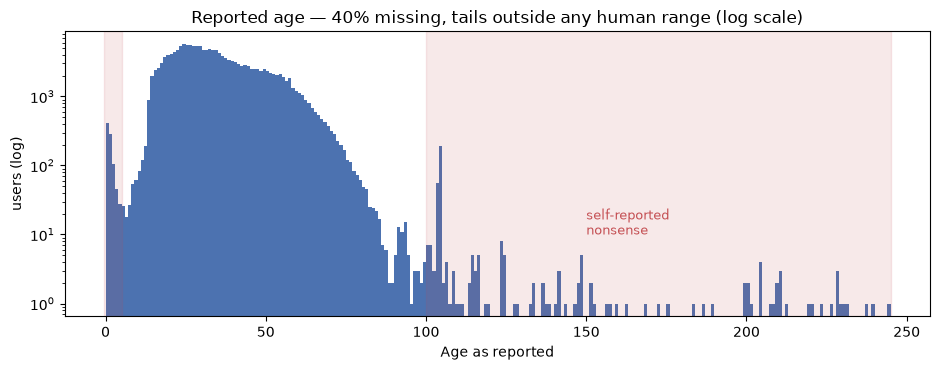

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 3.8))
ax.hist(age.dropna(), bins=np.arange(0, int(age.max()) + 2), color="#4c72b0")
ax.set_yscale("log")
ax.axvspan(-0.5, 5, color="#c44e52", alpha=0.12)
ax.axvspan(100, age.max() + 1, color="#c44e52", alpha=0.12)
ax.set_title(f"Reported age — {H['age_missing_share']:.0%} missing, tails outside any human range (log scale)")
ax.set_xlabel("Age as reported")
ax.set_ylabel("users (log)")
ax.annotate("self-reported\nnonsense", xy=(150, 10), color="#c44e52", fontsize=9)
fig.tight_layout()
plt.show()

**Takeaway.** Users.csv describes mostly people who never rated anything, with an age
column that is 40% empty and demonstrably self-reported — demography is therefore
**out of scope by decision**, which is a stronger position to defend than a
half-working demographic feature.

---
## 7 · No timestamps — and what that does to evaluation

**What and why.** `Ratings.csv` has exactly three columns: `User-ID`, `ISBN`,
`Book-Rating`. There is no time column anywhere in the dataset.

That has a direct consequence for how we are allowed to evaluate:

- **A temporal split is impossible here.** We cannot train on the past and test on the
  future, because the data does not know what the past is.
- **So evaluation uses per-user leave-N-out**: hold out N of a user's positive
  interactions, recommend, and check whether they come back. Split assignment is
  seeded so results are stable across runs.
- **This is a property of the PoC dataset, not of the method.** Production interaction
  logs carry timestamps. With client data we would split temporally, because a random
  split leaks future behaviour into training and flatters the model.

Worth stating out loud in the presentation: most public notebooks on Book-Crossing
either skip the split question or describe a temporal split that this dataset cannot
support.

---
## 8 · Sanity gallery

**What and why.** A face-validity check, nothing more. If the most-rated titles are
not recognisable bestsellers, something upstream is wrong.

In [16]:
titles = books.set_index("ISBN")["Book-Title"]
authors = books.set_index("ISBN")["Book-Author"]

most_rated = (
    per_book.sort_values(ascending=False).head(10).rename("interactions").to_frame()
    .assign(title=lambda d: d.index.map(titles), author=lambda d: d.index.map(authors))
    .reset_index()[["ISBN", "title", "author", "interactions"]]
)
print("Most interacted-with books (implicit + explicit):")
display(most_rated)
print(
    f"note: {int(most_rated['title'].isna().sum())} of these top 10 have no row in Books.csv — "
    "the §5 join gap, visible right at the head of the distribution."
)

MIN_VOTES = 50
exp_stats = explicit.groupby("ISBN")["Book-Rating"].agg(["mean", "size"])
top_rated = (
    exp_stats[exp_stats["size"] >= MIN_VOTES].sort_values("mean", ascending=False).head(10)
    .assign(title=lambda d: d.index.map(titles), author=lambda d: d.index.map(authors))
    .reset_index()[["ISBN", "title", "author", "mean", "size"]]
    .rename(columns={"mean": "avg_rating", "size": "n_explicit"})
)
print(f"\nHighest average explicit rating (at least {MIN_VOTES} explicit ratings):")
display(top_rated.round({"avg_rating": 2}))

Most interacted-with books (implicit + explicit):


,ISBN,title,author,interactions
0,0971880107,Wild Animus,Rich Shapero,2502
1,0316666343,The Lovely Bones: A Novel,Alice Sebold,1295
2,0385504209,The Da Vinci Code,Dan Brown,883
3,0060928336,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Rebecca Wells,732
4,0312195516,The Red Tent (Bestselling Backlist),Anita Diamant,723
5,044023722X,A Painted House,John Grisham,647
6,0679781587,NaN,NaN,639
7,0142001740,The Secret Life of Bees,Sue Monk Kidd,615
8,067976402X,Snow Falling on Cedars,David Guterson,614
9,0671027360,Angels &amp; Demons,Dan Brown,586


note: 1 of these top 10 have no row in Books.csv — the §5 join gap, visible right at the head of the distribution.

Highest average explicit rating (at least 50 explicit ratings):


,ISBN,title,author,avg_rating,n_explicit
0,0345339738,"The Return of the King (The Lord of the Rings, Part 3)",J.R.R. TOLKIEN,9.40,77
1,0439139597,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,9.26,137
2,043936213X,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,9.21,53
3,0345339711,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,9.12,83
4,0439136369,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,9.08,133
5,0064400557,Charlotte's Web (Trophy Newbery),E. B. White,9.07,68
6,0439136350,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,9.04,141
7,043935806X,Harry Potter and the Order of the Phoenix (Book 5),J. K. Rowling,9.03,206
8,0590353403,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,8.98,119
9,0156528207,The Little Prince,Antoine de Saint-ExupÃ©ry,8.98,51


**Takeaway.** The head of the distribution is the 2003 bestseller list and the
top-rated shelf is franchise fiction with devoted readers, so the data is what it
claims to be — but two details are worth keeping: the single most-interacted title is
*Wild Animus*, a novel its author gave away by the crate on BookCrossing rather than
one people sought out, and one of the top ten has no catalogue entry at all. Popularity
alone already produces plausible-looking output, which is exactly why a popularity
baseline has to be beaten rather than eyeballed.

---
## 9 · Ground-truth check

Every headline number recomputed above is compared against
`docs/dataset_findings.md`. A deviation is not a failure — it is
something to explain — so the check prints the difference rather than hiding it.

In [17]:
# (label, recomputed value, documented value, absolute tolerance)
CHECKS = [
    ("ratings, total",                  H["n_ratings"],              1_149_780, 0),
    ("books, total",                    H["n_books"],                  271_360, 0),
    ("users, total",                    H["n_users"],                  278_858, 0),
    ("implicit zeros",                  H["implicit_n"],               716_109, 0),
    ("implicit share",                  H["implicit_share"],             0.623, 0.0005),
    ("explicit ratings",                H["explicit_n"],               433_671, 0),
    ("explicit mean",                   H["explicit_mean"],                7.6, 0.05),
    ("explicit mode",                   H["explicit_mode"],                  8, 0),
    ("matrix density (all)",            H["density_all"],           0.000032, 0.0000005),
    ("books with exactly 1 rating",     H["books_1_rating"],             0.579, 0.0005),
    ("books with < 5 ratings",          H["books_lt5"],                  0.871, 0.0005),
    ("users with exactly 1 rating",     H["users_1_rating"],             0.562, 0.0005),
    ("top 1% of books, share of inter.", H["top1pct_share"],             0.251, 0.0005),
    ("ratings with unknown ISBN",       H["unmatched_n"],              118_644, 0),
    ("unknown-ISBN share",              H["unmatched_share"],            0.103, 0.0005),
    ("edition-duplicate works",         H["dupe_works"],                17_554, 0),
    ("edition-duplicate ISBNs",         H["dupe_isbns"],                40_675, 0),
    ("users with zero ratings",         H["users_zero_ratings"],       173_575, 0),
    ("Age missing share",               H["age_missing_share"],          0.397, 0.0005),
    ("Age implausible (of known)",      H["age_implausible_share"],     0.0074, 0.00005),
    ("Year == 0",                       H["year_zero"],                  4_618, 0),
    ("Year > 2006",                     H["year_future"],                   23, 0),
    ("malformed Books.csv rows",        H["n_malformed"],                    3, 0),
    ("filtered ratings (min-5/min-5)",  H["filtered_n"],               152_280, 0),
    ("filtered users",                  H["filtered_users"],            13_305, 0),
    ("filtered books",                  H["filtered_books"],            14_513, 0),
    ("filtered density",                H["filtered_density"],        0.00079, 0.000005),
]

print(f"{'number':<36}{'recomputed':>14}{'documented':>14}   status")
print("-" * 82)
deviations = []
for label, got, want, tol in CHECKS:
    ok = abs(got - want) <= tol
    fmt = (lambda v: f"{v:,}") if isinstance(got, int) else (lambda v: f"{v:.6g}")
    print(f"{label:<36}{fmt(got):>14}{fmt(want):>14}   {'match' if ok else 'DEVIATION'}")
    if not ok:
        deviations.append((label, got, want))

print("-" * 82)
print(f"{len(CHECKS) - len(deviations)}/{len(CHECKS)} match the ground-truth doc.")
if deviations:
    print("\nDeviations to explain (do not silently prefer either number):")
    for label, got, want in deviations:
        print(f"  - {label}: recomputed {got}, documented {want}")

number                                  recomputed    documented   status
----------------------------------------------------------------------------------
ratings, total                           1,149,780     1,149,780   match
books, total                               271,360       271,360   match
users, total                               278,858       278,858   match
implicit zeros                             716,109       716,109   match
implicit share                            0.622823         0.623   match
explicit ratings                           433,671       433,671   match
explicit mean                              7.60107           7.6   match
explicit mode                                    8             8   match
matrix density (all)                   3.20677e-05       3.2e-05   match
books with exactly 1 rating               0.578598         0.579   match
books with < 5 ratings                     0.87149         0.871   match
users with exactly 1 rating             

### Notes on definitions the ground-truth doc leaves implicit

Three numbers only reproduce under a specific definition. They are recorded here so
nobody has to re-derive them later:

1. **The min-5 funnel is a single pass.** Both thresholds are evaluated on the
   explicit-only set and applied together. Iterating the same filter to a fixed point
   removes a further ~22% (see §4) — the standard recipe does not, in the end,
   guarantee that every surviving user and book actually has 5 ratings. Reported
   numbers use the single pass, because that is what the public notebooks we compare
   against do.
2. **Edition duplicates are counted on lower-cased, whitespace-stripped title+author.**
   On raw strings the count is 15,746 works / 35,921 ISBNs; normalization is what
   yields the documented 17,554 / 40,675.
3. **"0.74% implausible ages" is a share of the ages we actually have**, not of all
   users (that would be 0.45%).

---
## What this means for the PoC

1. **Use both signals.** 62.3% implicit is too much to discard: binarize interactions
   for similarity, keep the explicit grade as a confidence weight.
2. **Measure coverage, not only accuracy.** A top 1% of books holding 25% of
   interactions means an accuracy-only leaderboard rewards recommending bestsellers.
3. **Plan for a content layer from the start.** Collaborative filtering can reach 5.3%
   of the catalogue; the remaining 95% needs title/author-based similarity.
4. **Normalize ISBNs in data prep.** 10.3% unresolvable joins and 40,675 duplicate-edition
   ISBNs are a data-prep problem, not a modelling one.
5. **Evaluate with per-user leave-N-out** and say plainly why: this dataset has no time.
6. **Skip demographics** by decision, and be able to say why in one sentence.

Every headline number above is recorded in [`docs/RESULTS.md`](../docs/RESULTS.md) —
the measurement ledger. Claims in the presentation bind to lines there, not to memory.